In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scripts import style
style.mpl_apply()  

In [113]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

In [114]:
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0
...,...,...,...,...,...,...,...,...,...
27783,177753,LAD,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,9.1,22446.0
27784,177677,LAD,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,RT,22446.0
27785,176090,LNI,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,2.8,22446.0
27786,181762,LIS,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,8.2,22446.0


In [115]:
materias.loc[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
3173,175199,LAT,2021,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
5191,175199,LDS,2023,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,NaN
6258,175199,LAT,2022,OTOÑO,0,MAT1022,CÁLCULO I,10,24827.0
14587,175199,LDS,2023,OTOÑO,0,MAT2012,CÁLCULO II,10,NaN
20218,175199,LDS,2023,OTOÑO,0,MAT1022,CÁLCULO I,10,NaN
26000,175199,LAT,2023,PRIMAVERA,0,MAT2012,CÁLCULO II,10,23874.0
27589,175199,LAT,2022,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0


Hay NaNs porque son las revalidadas?

In [116]:
# IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,0,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,0,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,0,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,0,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


In [117]:
materias['NUMORDEN'].nunique()

1

In [118]:
# drop NUMORDEN column
materias.drop(columns=['NUMORDEN'], inplace=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


In [16]:
materias[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
15962,175199,LAT,2021,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
15963,175199,LAT,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0
15964,175199,LAT,2022,OTOÑO,MAT1022,CÁLCULO I,10,24827.0
15965,175199,LAT,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,23874.0


In [119]:
# count nans
materias['CLAVEPROFESOR'].isna().sum()

np.int64(505)

In [ ]:
# drop the rows where CLAVEPROFESOR is nan
materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
# make the CLAVEPROFESOR column integer
materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152
...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149


Bien!

In [122]:
# clave profesor nunique
profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
profes_value_counts

CLAVEPROFESOR
23452    969
23411    772
23152    726
24097    720
23852    719
        ... 
24328     40
21756     30
21226     30
22472     30
26078     26
Name: count, Length: 77, dtype: int64

# Ver distribucion de calificaciones por profesor!

In [123]:
profe1 = materias[materias['CLAVEPROFESOR'] == 23452]

In [124]:
profe1

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
82,156299,LAP,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.9,23452
173,159060,LIM,2022,OTOÑO,MAT1032,ÁLGEBRA LINEAL,7.5,23452
184,159185,LAR,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23452
306,160271,LBN,2019,OTOÑO,MAT2012,CÁLCULO II,9.3,23452
394,161021,LEC,2024,OTOÑO,MAT1022,CÁLCULO I,0,23452
...,...,...,...,...,...,...,...,...
26177,186320,LFB,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,23452
26206,186400,LNI,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.7,23452
26227,186441,LBN,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,23452
26264,186512,LFP,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.7,23452


In [125]:
# keep the numeric calificacion numeric only
profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]
profe1num

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
82,156299,LAP,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.9,23452
173,159060,LIM,2022,OTOÑO,MAT1032,ÁLGEBRA LINEAL,7.5,23452
306,160271,LBN,2019,OTOÑO,MAT2012,CÁLCULO II,9.3,23452
394,161021,LEC,2024,OTOÑO,MAT1022,CÁLCULO I,0,23452
845,162163,LAR,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,1.2,23452
...,...,...,...,...,...,...,...,...
26177,186320,LFB,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,23452
26206,186400,LNI,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.7,23452
26227,186441,LBN,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,23452
26264,186512,LFP,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.7,23452


<Axes: xlabel='CALIFICACION', ylabel='Count'>

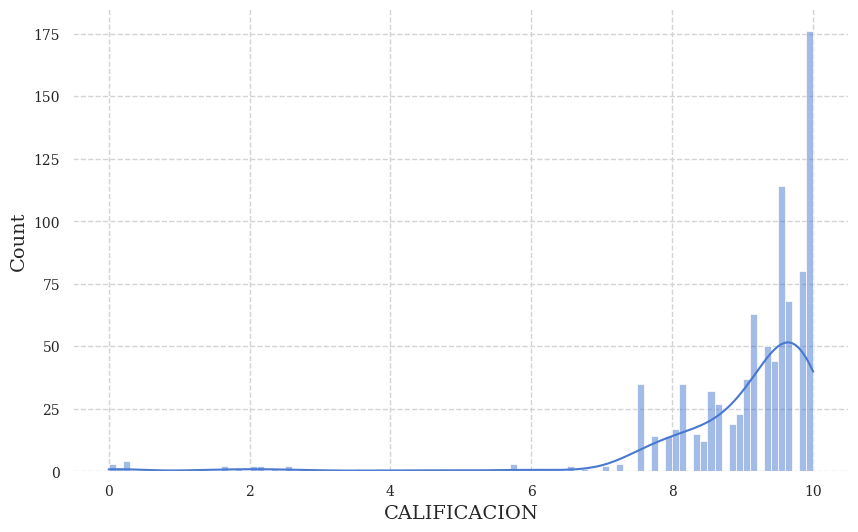

In [127]:
# plot the histogram of calificacion
plt.figure(figsize=(10, 6))
sns.histplot(profe1num['CALIFICACION'].astype(float), bins=100, kde=True)

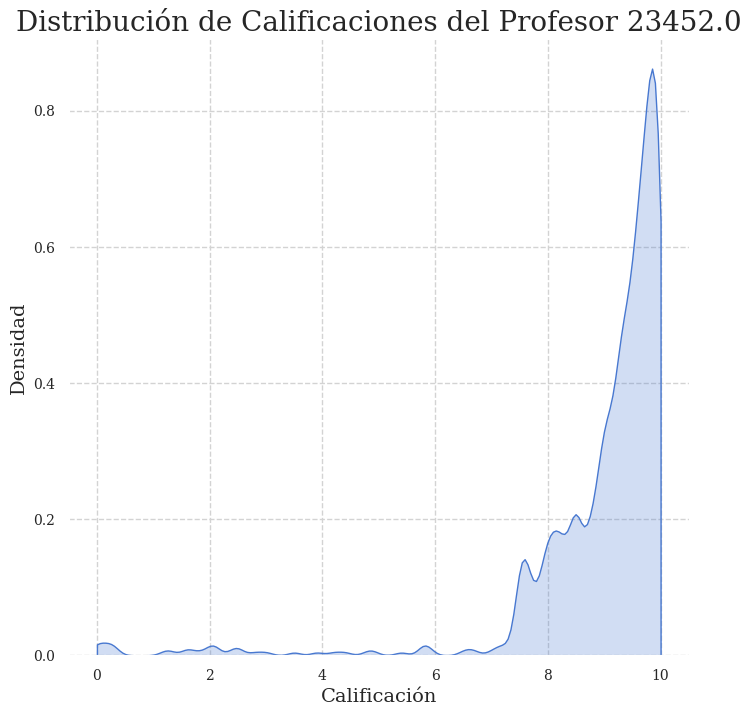

In [128]:
# plot only the kde, not the histogram, cut from 0 to 10
sns.kdeplot(profe1num['CALIFICACION'].astype(float), cut=0, bw_adjust=0.3, clip=(0, 10), fill=True)
plt.title('Distribución de Calificaciones del Profesor 23452.0')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
# remove the margin
plt.show()

In [129]:
# clave profesor nunique
profes_ids = materias['CLAVEPROFESOR'].unique()
profes_ids

array([23453, 21815, 22109, 24085, 23152, 24097, 23162, 23425, 23885,
       21228, 23468, 23434, 23411, 22446, 22767, 25093, 20792, 22091,
       22115, 24117, 23149, 23824, 23133, 23836, 23096, 22471, 23874,
       23852, 21779, 23839, 23837, 22521, 22503, 23887, 21854, 21852,
       16164, 21756, 23452, 23823, 23897, 18269, 24086, 20566, 23978,
       21853, 23859, 21262, 22114, 20529, 22473, 23218, 15282, 23148,
       21226, 22474, 22480, 23799, 23442, 23835, 20530, 24013, 24510,
       21192, 25487, 23153, 12516, 24328, 24827, 25496, 25503, 25843,
       25494, 22472, 25531, 26078, 25510])

In [ ]:
# plot all the densities in a loop
# sort profes_ids
profes_ids = sorted(profes_ids)
for num in range(len(profes_ids)):
    profe2 = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    # plot only the kde, not the histogram, cut from 0 to 10
    sns.kdeplot(profe2num['CALIFICACION'].astype(float), cut=0, bw_adjust=0.3, clip=(0, 10), fill=True)
    plt.xlim(0, 10)
    plt.title(f'Distribución de Calificaciones del Profesor {profes_ids[num]}')
    plt.xlabel('Calificación')
    plt.ylabel('Densidad')
    plt.savefig(f'visualizations/profes_distributions/professor/{profes_ids[num]}.png', bbox_inches='tight')
    plt.clf() # clear figure

<Figure size 800x800 with 0 Axes>

# All in a single plot!

In [135]:
profes_value_counts 

CLAVEPROFESOR
23452    969
23411    772
23152    726
24097    720
23852    719
        ... 
24328     40
21756     30
21226     30
22472     30
26078     26
Name: count, Length: 77, dtype: int64

In [136]:
# assign colors based on the counts
# for example 23452.0    969, this professor should have the darkest color and 26078.0     26, the lightest color
# first we do a min max scaling of the counts to 0-1
import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
counts = profes_value_counts.values.reshape(-1, 1) # this -1, 1 makes it a 2D array
scaled_counts = scaler.fit_transform(counts)

In [137]:
profes_value_counts.values.reshape(-1, 1)

array([[969],
       [772],
       [726],
       [720],
       [719],
       [708],
       [682],
       [651],
       [638],
       [618],
       [584],
       [584],
       [548],
       [536],
       [527],
       [525],
       [525],
       [519],
       [514],
       [511],
       [506],
       [493],
       [487],
       [484],
       [475],
       [471],
       [471],
       [470],
       [446],
       [443],
       [437],
       [397],
       [380],
       [373],
       [362],
       [347],
       [345],
       [335],
       [327],
       [323],
       [293],
       [290],
       [290],
       [288],
       [288],
       [276],
       [257],
       [235],
       [216],
       [204],
       [198],
       [181],
       [177],
       [165],
       [159],
       [142],
       [130],
       [123],
       [116],
       [107],
       [106],
       [ 97],
       [ 97],
       [ 95],
       [ 85],
       [ 71],
       [ 65],
       [ 65],
       [ 61],
       [ 58],
       [ 56],
      

In [ ]:
# assign colors of viridis based on the scaled counts, the higher the count, the brighter the color
colors = [sns.color_palette("viridis_r", 100)[int(scaled_counts[i][0]*99)] for i in range(len(scaled_counts))]

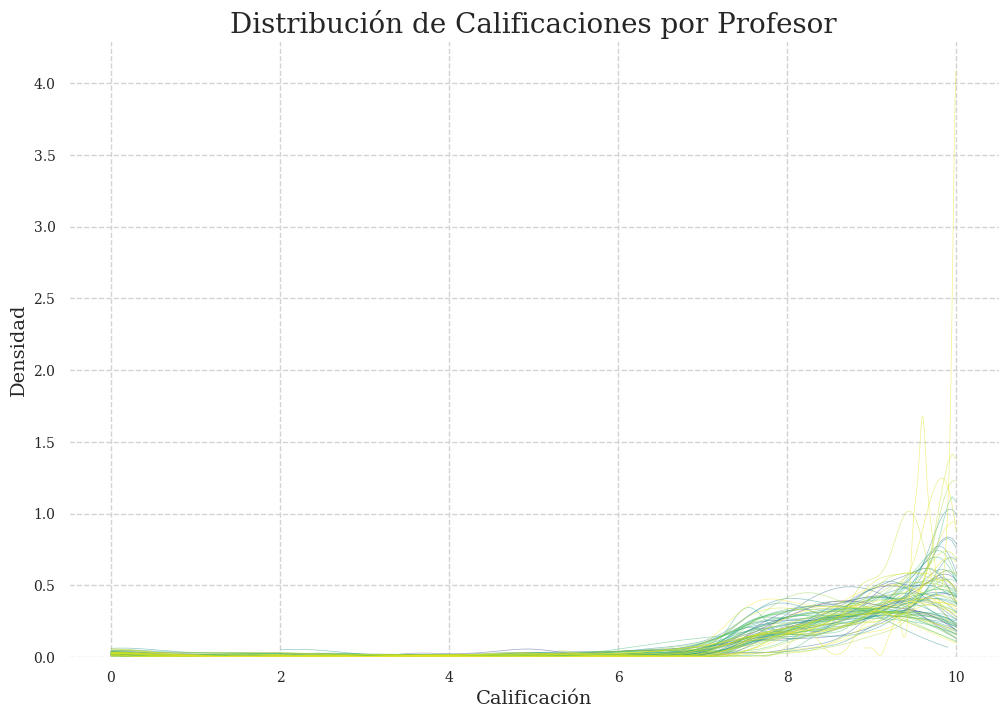

In [146]:
plt.figure(figsize=(12, 8))
for num in range(len(profes_ids)):
    profe2 = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue
    # plot only the kde, not the histogram, cut from 0 to 10
    sns.kdeplot(profe2num['CALIFICACION'], 
                cut=0, 
                bw_adjust=0.5, 
                clip=(0, 10), 
                label=f'Profesor {profes_ids[num]}', 
                alpha=0.5,  
                linewidth=0.5,
                color=colors[num])
plt.title('Distribución de Calificaciones por Profesor')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/all_professors.png', bbox_inches='tight')
plt.show()

# Estandarizacion en base a su media y desviacion estandar

# ESTOY DROPEANDO TODAS LAS NO NUMERICAS

In [156]:
materias = materias_copy.copy()

In [157]:
# view where there are not numeric calificaciones in materias
materias[~pd.to_numeric(materias['CALIFICACION'], errors='coerce').notnull()]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0
18,168811,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
19,168840,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
25,168285,LFP,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0
...,...,...,...,...,...,...,...,...,...
27746,180830,LNM,2024,PRIMAVERA,0,MAT1032,ÁLGEBRA LINEAL,BV,23148.0
27751,181679,LNM,2024,PRIMAVERA,0,MAT1032,ÁLGEBRA LINEAL,BV,23148.0
27768,184446,LMK,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,BV,22446.0
27780,183103,LNI,2025,PRIMAVERA,0,MAT1022,CÁLCULO I,RT,22446.0


In [150]:
# estandarizacion en base a su media y desviacion estandar para cada profesor, para cada clase

# keep only the numeric calificaciones
materias = materias[pd.to_numeric(materias['CALIFICACION'], errors='coerce').notnull()]

for profe_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == profe_id]
    for clase in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        clase_calificaciones = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == clase]['CALIFICACION']
        if not clase_calificaciones.empty:
            media = clase_calificaciones.mean()
            desviacion = clase_calificaciones.std()
            # aplicar estandarizacion
            materias.loc[(materias['CLAVEPROFESOR'] == profe_id) & (materias['CLAVEVARIANTEMATERIA'] == clase), 'CALIFICACIONESTANDARIZADA'] = (clase_calificaciones - media) / desviacion

In [151]:
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,CALIFICACIONESTANDARIZADA
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,0.158018,21815,0.158018
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,-0.114806,22109,-0.114806
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,0.40279,24085,0.40279
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,0.582506,23152,0.582506
10,140079,LNA,2023,OTOÑO,MAT1032,ÁLGEBRA LINEAL,0.725163,24097,0.725163
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,0.049518,23453,0.049518
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,-0.102466,23897,-0.102466
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,-0.010846,22446,-0.010846
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,0.563996,23149,0.563996


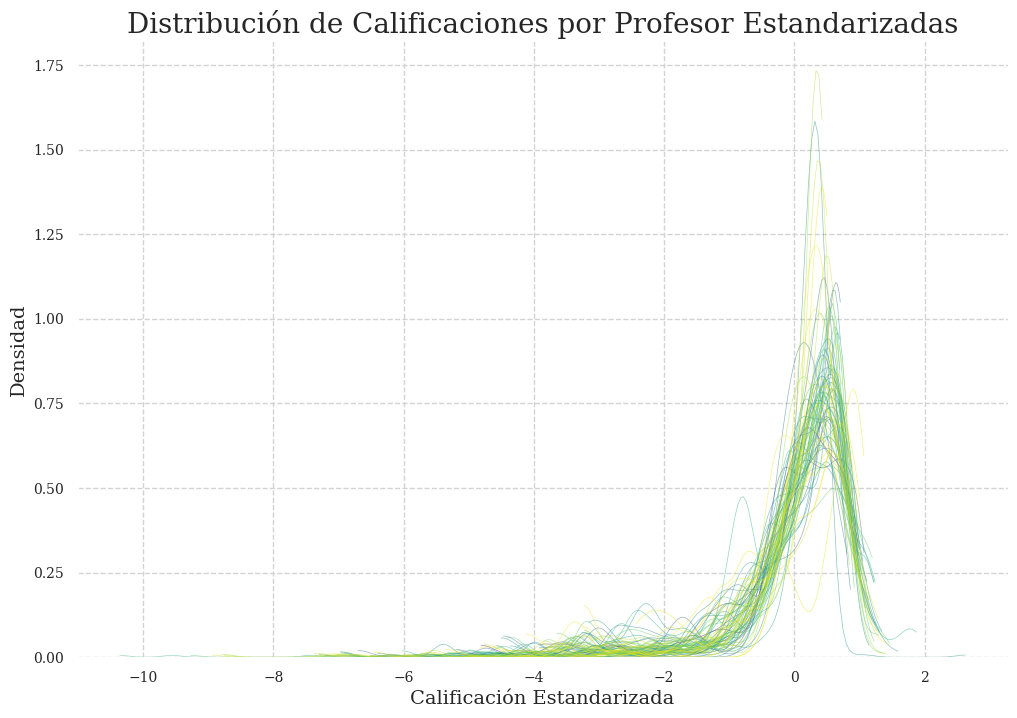

In [155]:
plt.figure(figsize=(12, 8))
for num in range(len(profes_ids)):
    profe2 = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue
    # plot only the kde, not the histogram, cut from 0 to 10
    sns.kdeplot(profe2num['CALIFICACION'], 
                cut=0, 
                bw_adjust=0.5, 
                label=f'Profesor {profes_ids[num]}', 
                alpha=0.5,  
                linewidth=0.5,
                color=colors[num])
plt.title('Distribución de Calificaciones por Profesor Estandarizadas')
plt.xlabel('Calificación Estandarizada')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/all_professors_estandarized.png', bbox_inches='tight')
plt.show()